In [68]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, mean_absolute_error
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

In [69]:
data = pd.read_csv("processed_data.csv")

In [15]:
forward_features = ['Study_Hours', 'Internal_Assessment_Score', 'Previous_Academic_Result']
backward_features = ['Study_Hours', 'Internal_Assessment_Score', 'Previous_Academic_Result']

In [16]:
#Regression Forward
X_f = data[forward_features]
y = data['Final_Grade']

X_train, X_test, y_train, y_test = train_test_split(X_f, y, test_size=0.2, random_state=42)

model_f = LinearRegression()
model_f.fit(X_train, y_train)

y_pred_f = model_f.predict(X_test)

r2_forward = r2_score(y_test, y_pred_f)
rmse_forward = np.sqrt(mean_squared_error(y_test, y_pred_f))
mae_forward = mean_absolute_error(y_test, y_pred_f)
mse_forward = mean_squared_error(y_test, y_pred_f)

print("Forward R2:", r2_forward)
print("Forward RMSE:", rmse_forward)
print("Forward MSE:", mse_forward)
print("Forward MAE:", mae_forward)

Forward R2: 0.6895301407018808
Forward RMSE: 10.268094348613122
Forward MSE: 105.43376155202074
Forward MAE: 7.275719463741162


In [17]:
#Regression Backward
X_b = data[backward_features]

X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)

model_b = LinearRegression()
model_b.fit(X_train, y_train)

y_pred_b = model_b.predict(X_test)

r2_backward = r2_score(y_test, y_pred_b)
rmse_backward = np.sqrt(mean_squared_error(y_test, y_pred_b))
mae_backward = mean_absolute_error(y_test, y_pred_b)
mse_backward = mean_squared_error(y_test, y_pred_b)

print("Backward R2:", r2_backward)
print("Backward RMSE:", rmse_backward)
print("Backward MSE:", mse_backward)
print("Backward MAE:", mae_backward)

Backward R2: 0.6895301407018808
Backward RMSE: 10.268094348613122
Backward MSE: 105.43376155202074
Backward MAE: 7.275719463741162


In [19]:
print(" Feature Selection Comparison")

print("\nForward Selection:")
print("R2:", r2_forward)
print("RMSE:", rmse_forward)
print("MSE:", mse_forward)
print("MAE:", mae_forward)

print("\nBackward Selection:")
print("R2:", r2_backward)
print("RMSE:", rmse_backward)
print("MSE:", mse_backward)
print("MAE:", mae_backward)

 Feature Selection Comparison

Forward Selection:
R2: 0.6895301407018808
RMSE: 10.268094348613122
MSE: 105.43376155202074
MAE: 7.275719463741162

Backward Selection:
R2: 0.6895301407018808
RMSE: 10.268094348613122
MSE: 105.43376155202074
MAE: 7.275719463741162


In [20]:
print("--- Final Decision ---")

if (r2_forward > r2_backward) and (rmse_forward < rmse_backward):
    print("Forward Selection is better")
    best_features = forward_features

elif (r2_backward > r2_forward) and (rmse_backward < rmse_forward):
    print("Backward Selection is better")
    best_features = backward_features

elif abs(r2_forward - r2_backward) < 0.01:   # almost same performance
    print("Both Forward and Backward give similar performance")
    
    if rmse_forward < rmse_backward:
        print("selecting Forward")
        best_features = forward_features
    else:
        print("selecting Backward")
        best_features = backward_features

else:
    print("Mixed results:selecting Forward for simplicity") #Backward has better R² -Forward has better RMSE
    best_features = forward_features

print("Best Features:", best_features)

--- Final Decision ---
Both Forward and Backward give similar performance
selecting Backward
Best Features: ['Study_Hours', 'Internal_Assessment_Score', 'Previous_Academic_Result']


In [21]:
#Final Linear Regression Model
X = data[best_features]
y = data['Final_Grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

final_model = LinearRegression()
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

print("Final R2:", r2_score(y_test, y_pred))
print("Final RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Final MAE:", mean_absolute_error(y_test, y_pred))
print("Final MSE:",mean_squared_error(y_test, y_pred_f))

Final R2: 0.6895301407018808
Final RMSE: 10.268094348613122
Final MAE: 7.275719463741162
Final MSE: 105.43376155202074


In [22]:
# Regression using Decision Tree

X_dt = data[best_features]
y = data['Final_Grade']

X_train, X_test, y_train, y_test = train_test_split(X_dt, y, test_size=0.2, random_state=42)

model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)

print(" Decision Tree Regression ")
print("R2:", r2_dt)
print("RMSE:", rmse_dt)
print("MSE:", mse_dt)
print("MAE:", mae_dt)

 Decision Tree Regression 
R2: 0.7180275140132586
RMSE: 9.785510668245712
MSE: 95.75621903835062
MAE: 3.6408308823529416


In [25]:
# Regression using Random Forest

X_rf = data[best_features]
y = data['Final_Grade']

X_train, X_test, y_train, y_test = train_test_split(X_rf, y, test_size=0.2, random_state=42)

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print(" Random Forest Regression ")
print("R2:", r2_rf)
print("RMSE:", rmse_rf)
print("MSE:", mse_rf)
print("MAE:", mae_rf)

 Random Forest Regression 
R2: 0.8309515454736454
RMSE: 7.576798375274409
MSE: 57.407873619560924
MAE: 3.247565952390375


In [26]:
print(" Model Comparison ")
print("Linear R2:", r2_forward)
print("Decision Tree R2:", r2_dt)
print("Random Forest R2:", r2_rf)

 Model Comparison 
Linear R2: 0.6895301407018808
Decision Tree R2: 0.7180275140132586
Random Forest R2: 0.8309515454736454


In [27]:
# Classification
X = data[best_features]
y = data['Result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

c_model = LogisticRegression()
c_model.fit(X_train, y_train)

y_pred = c_model.predict(X_test)
train_acc = c_model.score(X_train, y_train)
test_acc = c_model.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(" Classification Model ")
print("Accuracy:", accuracy)
print("\nPrecision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)


Training Accuracy: 0.880875
Testing Accuracy: 0.8825
 Classification Model 
Accuracy: 0.8825

Precision: 0.9050097592713078
Recall: 0.9398648648648649
F1 Score: 0.9221080543586344

Confusion Matrix:
 [[ 374  146]
 [  89 1391]]


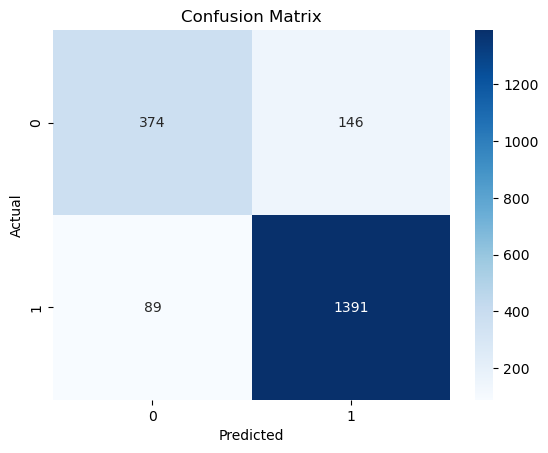

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [29]:
X = data[best_features]
y = data['Result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

svm_model = SVC(kernel='linear')   
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

train_acc_svm = svm_model.score(X_train, y_train)
test_acc_svm = svm_model.score(X_test, y_test)

print(" SVM Classification ")
print("Training Accuracy:", train_acc_svm)
print("Testing Accuracy:", test_acc_svm)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))

cm_svm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:\n", cm_svm)

 SVM Classification 
Training Accuracy: 0.906125
Testing Accuracy: 0.9095
Accuracy: 0.9095
Precision: 0.9242325277596343
Recall: 0.956081081081081
F1 Score: 0.939887080704085
Confusion Matrix:
 [[ 404  116]
 [  65 1415]]


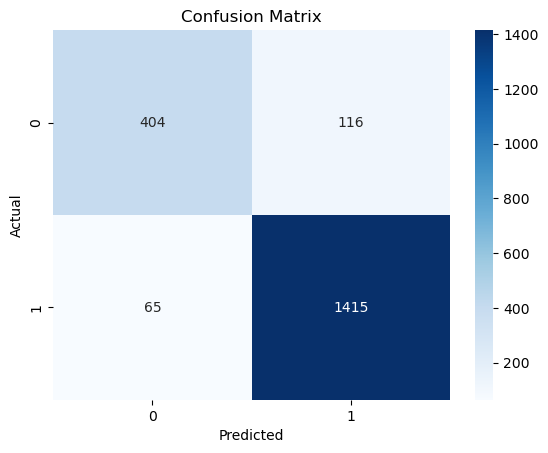

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [31]:
X = data[best_features]
y = data['Result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42) #Number of decision trees in the forest
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

train_acc_rf = rf_model.score(X_train, y_train)
test_acc_rf = rf_model.score(X_test, y_test)

print(" Random Forest Classification ")
print("Training Accuracy:", train_acc_rf)
print("Testing Accuracy:", test_acc_rf)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm_rf)

 Random Forest Classification 
Training Accuracy: 0.99225
Testing Accuracy: 0.9475
Accuracy: 0.9475
Precision: 0.9508196721311475
Recall: 0.9797297297297297
F1 Score: 0.9650582362728786
Confusion Matrix:
 [[ 445   75]
 [  30 1450]]


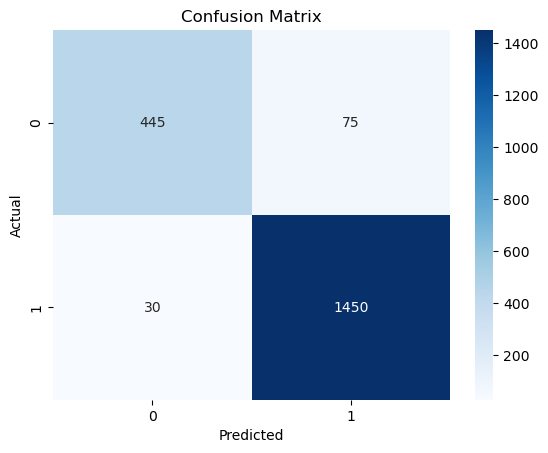

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [33]:
print("Logistic Regression")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

print("\nSVM")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1:", f1_score(y_test, y_pred_svm))

print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))

Logistic Regression
Accuracy: 0.8825
Precision: 0.9050097592713078
Recall: 0.9398648648648649
F1: 0.9221080543586344

SVM
Accuracy: 0.9095
Precision: 0.9242325277596343
Recall: 0.956081081081081
F1: 0.939887080704085

Random Forest
Accuracy: 0.9475
Precision: 0.9508196721311475
Recall: 0.9797297297297297
F1: 0.9650582362728786


In [40]:
# MODEL TRAINING BY USING PCA
X_pca_df = pd.read_csv("pca_data.csv")

In [41]:
# PCA Linear Regression

X = X_pca_df
y = data['Final_Grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(" PCA Linear Regression ")
print("R2:", r2)
print("RMSE:", rmse)
print("MSE:", mse)
print("MAE:", mae)


--- PCA Linear Regression ---
R2: 0.6901665638723045
RMSE: 10.257564815226704
MSE: 105.21763593857686
MAE: 7.335080331165885


In [42]:
# PCA Decision Tree Regression

X = X_pca_df
y = data['Final_Grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2_dt = r2_score(y_test, y_pred)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred))
mse_dt = mean_squared_error(y_test, y_pred)
mae_dt = mean_absolute_error(y_test, y_pred)

print(" PCA Decision Tree ")
print("R2:", r2_dt)
print("RMSE:", rmse_dt)
print("MSE:", mse_dt)
print("MAE:", mae_dt)

 PCA Decision Tree 
R2: 0.39008085588035757
RMSE: 14.391837964624255
MSE: 207.125
MAE: 8.425


In [44]:
# PCA Random Forest Regression

X = X_pca_df
y = data['Final_Grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2_rf = r2_score(y_test, y_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred))
mse_rf = mean_squared_error(y_test, y_pred)
mae_rf = mean_absolute_error(y_test, y_pred)

print(" PCA Random Forest ")
print("R2:", r2_rf)
print("RMSE:", rmse_rf)
print("MSE:", mse_rf)
print("MAE:", mae_rf)

 PCA Random Forest 
R2: 0.6768368776034175
RMSE: 10.475892324761649
MSE: 109.74432
MAE: 7.3657


In [62]:
# PCA Logistic Regression

X = X_pca_df
y = data['Result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred_log = model.predict(X_test)

print(" PCA Logistic Regression ")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

cm_log_pca = confusion_matrix(y_test, y_pred_log)
print("Confusion Matrix:\n", cm_log_pca)

 PCA Logistic Regression 
Accuracy: 0.88
Precision: 0.9015544041450777
Recall: 0.9405405405405406
F1 Score: 0.9206349206349206
Confusion Matrix:
 [[ 368  152]
 [  88 1392]]


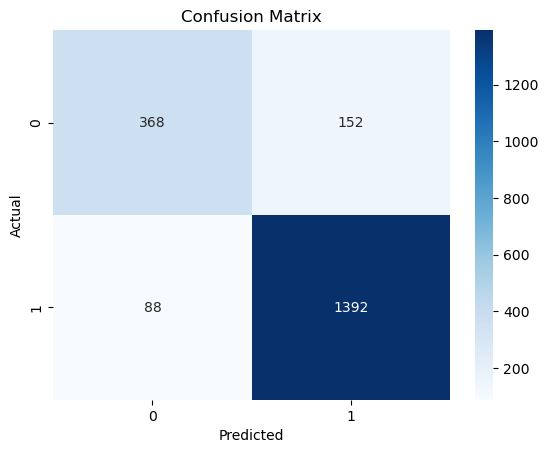

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_log_pca, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [61]:
# PCA SVM Classification

X = X_pca_df
y = data['Result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = SVC(kernel='linear')
model.fit(X_train, y_train)

y_pred_svm = model.predict(X_test)

print(" PCA SVM ")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))

cm_svm_pca = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:\n", cm_svm_pca)

 PCA SVM 
Accuracy: 0.8845
Precision: 0.9021249195106246
Recall: 0.9466216216216217
F1 Score: 0.923837784371909
Confusion Matrix:
 [[ 368  152]
 [  79 1401]]


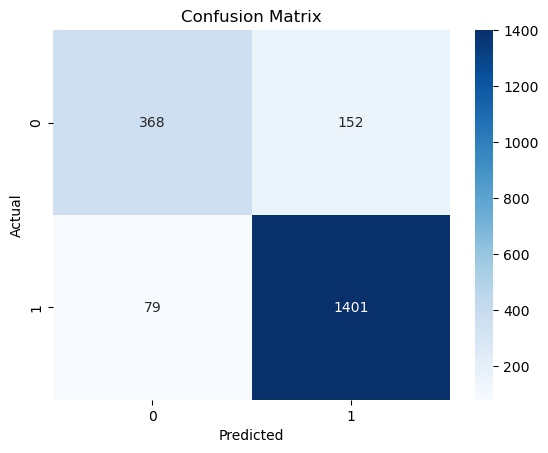

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_svm_pca, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [63]:
# PCA Random Forest Classification

X = X_pca_df
y = data['Result']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred_rf = model.predict(X_test)

print(" PCA Random Forest ")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

cm_rf_pca = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm_rf_pca)

 PCA Random Forest 
Accuracy: 0.8885
Precision: 0.8925671455340413
Recall: 0.9655405405405405
F1 Score: 0.9276209023044466
Confusion Matrix:
 [[ 348  172]
 [  51 1429]]


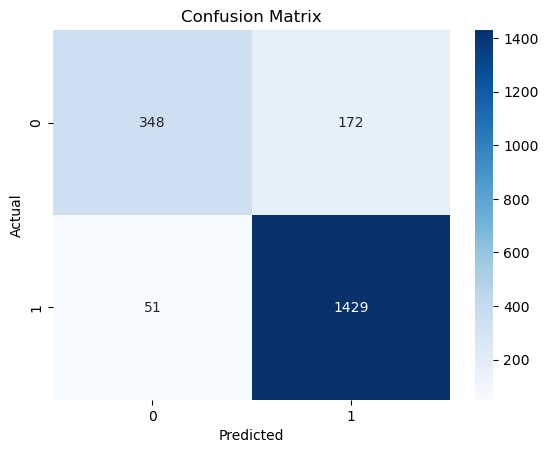

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_rf_pca, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [59]:
print(" PCA Regression Model Comparison ")

print("PCA Linear R2:", r2)
print("PCA Decision Tree R2:", r2_dt)
print("PCA Random Forest R2:", r2_rf)

print("\nPCA Linear RMSE:", rmse)
print("PCA Decision Tree RMSE:", rmse_dt)
print("PCA Random Forest RMSE:", rmse_rf)

print("\nPCA Linear MSE:", mse)
print("PCA Decision Tree MSE:", mse_dt)
print("PCA Random Forest MSE:", mse_rf)

print("\nPCA Linear MAE:", mae)
print("PCA Decision Tree MAE:", mae_dt)
print("PCA Random Forest MAE:", mae_rf)

 PCA Regression Model Comparison 
PCA Linear R2: 0.6901665638723045
PCA Decision Tree R2: 0.39008085588035757
PCA Random Forest R2: 0.6768368776034175

PCA Linear RMSE: 10.257564815226704
PCA Decision Tree RMSE: 14.391837964624255
PCA Random Forest RMSE: 10.475892324761649

PCA Linear MSE: 105.21763593857686
PCA Decision Tree MSE: 207.125
PCA Random Forest MSE: 109.74432

PCA Linear MAE: 7.335080331165885
PCA Decision Tree MAE: 8.425
PCA Random Forest MAE: 7.3657


In [64]:
print(" PCA Classification Model Comparison ")

print("PCA Logistic Accuracy:", accuracy_score(y_test, y_pred_log))
print("PCA SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("PCA Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nPCA Logistic Precision:", precision_score(y_test, y_pred_log))
print("PCA SVM Precision:", precision_score(y_test, y_pred_svm))
print("PCA Random Forest Precision:", precision_score(y_test, y_pred_rf))

print("\nPCA Logistic Recall:", recall_score(y_test, y_pred_log))
print("PCA SVM Recall:", recall_score(y_test, y_pred_svm))
print("PCA Random Forest Recall:", recall_score(y_test, y_pred_rf))

print("\nPCA Logistic F1:", f1_score(y_test, y_pred_log))
print("PCA SVM F1:", f1_score(y_test, y_pred_svm))
print("PCA Random Forest F1:", f1_score(y_test, y_pred_rf))

 PCA Classification Model Comparison 
PCA Logistic Accuracy: 0.88
PCA SVM Accuracy: 0.8845
PCA Random Forest Accuracy: 0.8885

PCA Logistic Precision: 0.9015544041450777
PCA SVM Precision: 0.9021249195106246
PCA Random Forest Precision: 0.8925671455340413

PCA Logistic Recall: 0.9405405405405406
PCA SVM Recall: 0.9466216216216217
PCA Random Forest Recall: 0.9655405405405405

PCA Logistic F1: 0.9206349206349206
PCA SVM F1: 0.923837784371909
PCA Random Forest F1: 0.9276209023044466
